In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
print("Libraries Loaded")

Libraries Loaded


In [2]:
df = pd.read_csv("data/train.csv")
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
#Explore
print("Column names:")
print(df.columns.tolist())
print("Info",df.info())
print("\nMissing values",df.isnull().sum())
print("\nStatistical info\n",df.describe())

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13 

In [4]:
#Data Cleaning
df.drop_duplicates(inplace=True)
print(df.shape)

(9800, 18)


In [5]:
# TRANSFORM 

# create a safe copy of dataset
df_copy = df.copy()

# clean column names
df_copy.columns = (df_copy.columns.str.strip().str.lower().str.replace(' ', '_'))
print("Cleaned column names:")
print(df_copy.columns.tolist())

# DATE CONVERSION
df_copy['order_date'] = pd.to_datetime(df_copy['order_date'],dayfirst=True)
df_copy['ship_date'] = pd.to_datetime(df_copy['ship_date'],dayfirst=True)

# DATE FEATURES
df_copy['order_year'] = df_copy['order_date'].dt.year
df_copy['order_month'] = df_copy['order_date'].dt.month
df_copy['order_month_name'] = df_copy['order_date'].dt.strftime('%b')
df_copy['order_quarter'] = df_copy['order_date'].dt.quarter

# SHIPPING DAYS
df_copy['ship_days'] = (df_copy['ship_date'] - df_copy['order_date']).dt.days

# PROFIT MARGIN
#df_copy['profit_margin'] = (df_copy['profit'] / df_copy['sales']) * 100
#df_copy['profit_margin'] = df_copy['profit_margin'].round(2)

# SALES CATEGORY
df_copy['sales_category'] = pd.cut( df_copy['sales'],bins=[0, 100, 500, df_copy['sales'].max()],labels=['Low', 'Medium', 'High'])

print(df_copy.head())
print("\nShape:", df_copy.shape)

Cleaned column names:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales']
   row_id        order_id order_date  ship_date       ship_mode customer_id  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     customer_name    segment        country             city  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ... 

In [6]:
import os
os.makedirs("outputs", exist_ok=True)
os.makedirs("charts", exist_ok=True)

In [7]:
import sqlite3
conn = sqlite3.connect("outputs/retail_sales.db")
df_copy.to_sql("sales",conn,if_exists="replace",index=False)
print("Database created successfully!")

Database created successfully!


In [12]:
#Sales category
query1 = """
SELECT 
    category,
    SUM(sales) AS total_sales
FROM sales
GROUP BY category
ORDER BY total_sales DESC
"""
category_df = pd.read_sql(query1, conn)
category_df

,category,total_sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


In [13]:
#Sales by region
query2 = """
SELECT region,
SUM(sales) AS total_sales
FROM sales
GROUP BY region
ORDER BY total_sales DESC
"""
region_df = pd.read_sql(query2, conn)
region_df

,region,total_sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


In [14]:
#Monthly Sales trend
query3 = """
SELECT order_year,
order_month_name,
SUM(sales) AS monthly_sales
FROM sales
GROUP BY order_year, order_month_name
ORDER BY order_year
"""
monthly_df = pd.read_sql(query3, conn)
monthly_df

,order_year,order_month_name,monthly_sales
0,2015,Apr,27906.8550
1,2015,Aug,27117.5365
2,2015,Dec,68167.0585
3,2015,Feb,4519.8920
4,2015,Jan,14205.7070
5,2015,Jul,33781.5430
6,2015,Jun,34322.9356
7,2015,Mar,55205.7970
8,2015,May,23644.3030
9,2015,Nov,77907.6607


In [15]:
#Top Customers
query4 = """
SELECT customer_name,
SUM(sales) AS total_sales
FROM sales
GROUP BY customer_name
ORDER BY total_sales DESC
LIMIT 10
"""
top_customers = pd.read_sql(query4, conn)
top_customers

,customer_name,total_sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


In [16]:
#Shipping Delay Analysis
query5 = """
SELECT order_id,
ship_days,
sales
FROM sales
ORDER BY ship_days DESC
LIMIT 10
"""
delay_df = pd.read_sql(query5, conn)
delay_df

,order_id,ship_days,sales
0,US-2016-108966,7,957.5775
1,US-2016-108966,7,22.3680
2,CA-2015-105893,7,665.8800
3,CA-2018-155558,7,19.9900
4,CA-2018-155558,7,6.1600
5,CA-2017-128867,7,75.9600
6,CA-2017-128867,7,27.2400
7,US-2018-107272,7,2.3880
8,US-2018-107272,7,243.9920
9,CA-2018-107720,7,46.2600


In [17]:
#Insights
print("Total sales:", df_copy['sales'].sum())
print("Average shipping days:", df_copy['ship_days'].mean())

print("\nBest Category:")
print(category_df.iloc[0])

print("\nBest Region:")
print(region_df.iloc[0])

Total sales: 2261536.7827
Average shipping days: 3.9611224489795918

Best Category:
category       Technology
total_sales    827455.873
Name: 0, dtype: object

Best Region:
region                West
total_sales    710219.6845
Name: 0, dtype: object


In [18]:
category_df.to_csv("outputs/category.csv", index=False)
region_df.to_csv("outputs/region.csv", index=False)
monthly_df.to_csv("outputs/monthly.csv", index=False)
top_customers.to_csv("outputs/top_customers.csv", index=False)
delay_df.to_csv("outputs/delay.csv", index=False)
df_copy.to_csv("outputs/cleaned_data.csv", index=False)
conn.close()
print("exported successfully!")

exported successfully!


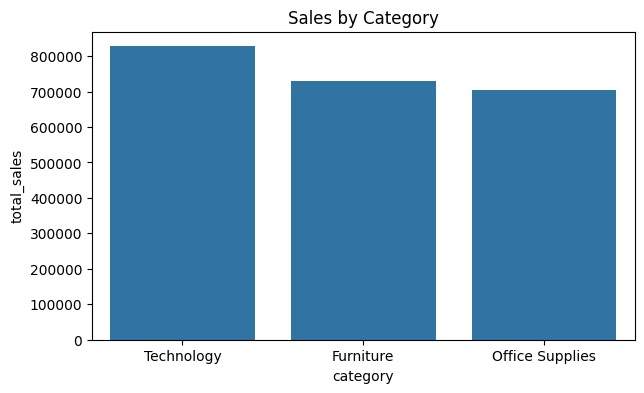

In [19]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Sales by Category
plt.figure(figsize=(7,4))
sns.barplot(data=category_df,x="category",y="total_sales")
plt.title("Sales by Category")
plt.show()

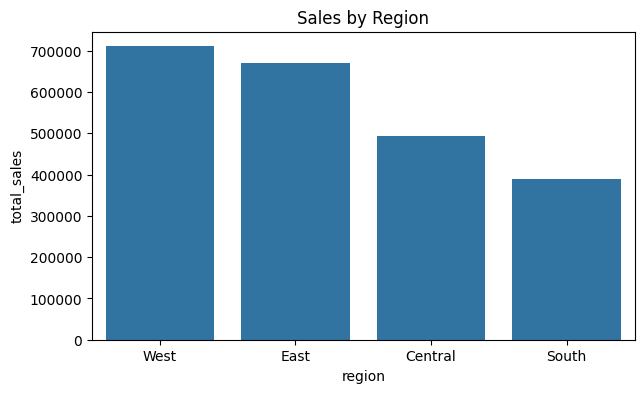

In [20]:
#Sales by region
plt.figure(figsize=(7,4))
sns.barplot(data=region_df,x="region",y="total_sales")
plt.title("Sales by Region")
plt.show()

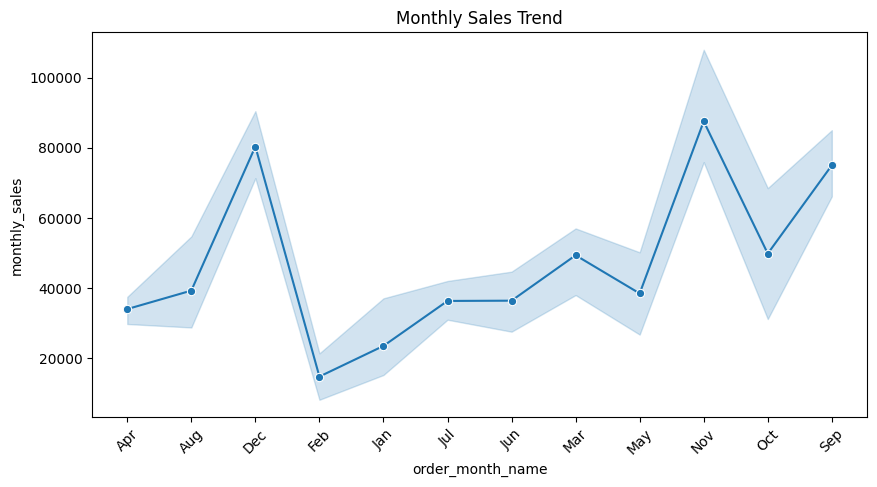

In [21]:
#Monthly sales trend
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_df,x="order_month_name",y="monthly_sales",marker="o")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

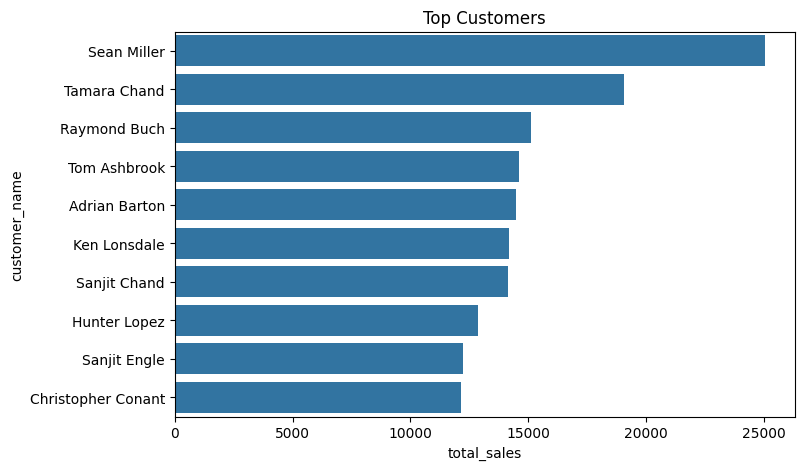

In [22]:
#Top customers
plt.figure(figsize=(8,5))
sns.barplot(data=top_customers,x="total_sales",y="customer_name")
plt.title("Top Customers")
plt.show()

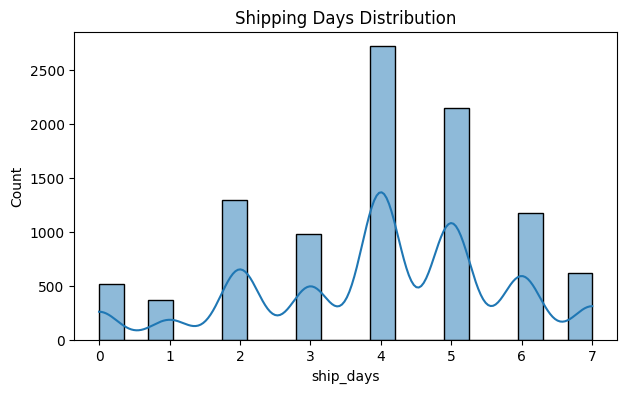

In [23]:
#Shipping delay distribution
plt.figure(figsize=(7,4))
sns.histplot(df_copy["ship_days"], bins=20, kde=True)
plt.title("Shipping Days Distribution")
plt.show()